# Introduction

Το παρόν project αποτελεί μια ολοκληρωμένη διερεύνηση του Customer Churn για ένα retail banking dataset με 10.000 πελάτες.
Στόχος είναι ο εντοπισμός των παραγόντων που συνδέονται με την αποχώρηση πελατών και η αποτίμηση της ισχύος τους μέσω στατιστικών δοκιμών, μέτρων συσχέτισης και ανάλυσης αλληλεπιδράσεων.

Η μεθοδολογία περιλαμβάνει:

- Univariate exploratory analysis

- Welch’s t-test με FDR correction για αριθμητικές μεταβλητές

- Chi-square test & Cramér’s V για κατηγορικές

- Mutual Information για nonlinear σχέσεις

- Investigation of interaction effects μέσω logistic regression

- Visualization των patterns για data-driven insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid")

CHURN_COLOR = "#d62728"   # κόκκινο για churn
RETAIN_COLOR = "#1f77b4"  # μπλε για non-churn

def set_plot_style():
    plt.rcParams['figure.figsize'] = (6,4)
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['figure.dpi'] = 120

set_plot_style()

In [3]:
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# 1. Load Data

In [4]:
from pathlib import Path
import pandas as pd

# Base directory = φάκελος όπου είναι το notebook
BASE_DIR = Path().resolve()

# Σωστό, portable relative path
data_path = BASE_DIR / "data" / "processed" / "bank_churn_cleaned_final.csv"

df = pd.read_csv(data_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print("Shape:", df.shape)
df.head()

Shape: (10000, 13)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_capped
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,42
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,42
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,39
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,43


In [27]:
# 🔧 Διόρθωση τύπων δεδομένων για σωστή ανάλυση & μοντελοποίηση

# Binary ή numeric features => int
for col in ['churn', 'active_member', 'credit_card']:
    df[col] = df[col].astype(int)

# Categorical πραγματικά => category
for col in ['country', 'gender']:
    df[col] = df[col].astype('category')

# Αν products_number το χειριστείς ως αριθμητικό
df['products_number'] = df['products_number'].astype(int)

# Έλεγχος
df.dtypes

customer_id            int64
credit_score           int64
country             category
gender              category
age                    int64
tenure                 int64
balance              float64
products_number        int32
credit_card            int32
active_member          int32
estimated_salary     float64
churn                  int32
age_capped             int64
age_group           category
dtype: object

# 2. Statistical Comparison: Welch’s t-test
Για κάθε αριθμητική μεταβλητή εξετάζουμε αν ο μέσος όρος διαφέρει σημαντικά μεταξύ:

churn = 0 (customers who stayed)
churn = 1 (customers who left)
Χρησιμοποιούμε το Welch’s t-test, που δεν υποθέτει ίσες διασπορές,
και εφαρμόζουμε FDR correction (Benjamini–Hochberg) ώστε να αποφύγουμε πολλαπλά σφάλματα τύπου Ι.

Επιπλέον υπολογίζουμε:

Cohen’s d (effect size) → πόσο μεγάλη είναι η διαφορά

In [30]:
# 📊 Welch’s t-test για αριθμητικές μεταβλητές + FDR correction + Cohen’s d

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def welch_ttest_numeric(df, target='churn'):
    
    num_features = df.select_dtypes(
        include=['int32','int64','float32','float64']
    ).columns.drop(target)

    results = []

    def cohens_d(x, y):
        nx, ny = len(x), len(y)
        pooled_std = np.sqrt(((nx - 1)*x.std()**2 + (ny - 1)*y.std()**2) / (nx + ny - 2))
        return (x.mean() - y.mean()) / pooled_std

    for col in num_features:
        g0 = df.loc[df[target] == 0, col].dropna()
        g1 = df.loc[df[target] == 1, col].dropna()

        t_stat, p_value = ttest_ind(g0, g1, equal_var=False)
        d = cohens_d(g0, g1)

        results.append({
            'feature': col,
            't_stat': t_stat,
            'p_value': p_value,
            'mean_churn0': g0.mean(),
            'mean_churn1': g1.mean(),
            'cohen_d': d
        })

    t_df = pd.DataFrame(results)

    t_df['reject'], t_df['p_adj'], _, _ = multipletests(
        t_df['p_value'], alpha=0.05, method='fdr_bh'
    )

    def interpret_d(d):
        d = abs(d)
        if d < 0.2: return 'Small'
        elif d < 0.5: return 'Medium'
        else: return 'Large'

    t_df['effect_strength'] = t_df['cohen_d'].apply(interpret_d)

    return t_df.sort_values('p_adj').reset_index(drop=True)

In [7]:
numeric_results = welch_ttest_numeric(df)
numeric_results

,feature,t_stat,p_value,mean_churn0,mean_churn1,cohen_d,reject,p_adj,effect_strength
0,age_capped,-30.474011,1.389468e-179,3.740211e+01,4.483603e+01,-0.741346,True,1.389468e-178,Large
1,age,-30.419197,4.712727e-179,3.740839e+01,4.483800e+01,-0.739092,True,2.356364e-178,Large
2,active_member,16.128143,2.384770e-56,5.545649e-01,3.608247e-01,0.392431,True,7.949234e-56,Medium
3,balance,-12.471280,6.318664e-35,7.274530e+04,9.110854e+04,-0.296370,True,1.579666e-34,Medium
4,products_number,3.701998,2.185849e-04,1.544267e+00,1.475209e+00,0.118858,True,4.371699e-04,Small
5,credit_score,2.634661,8.464729e-03,6.518532e+02,6.453515e+02,0.067290,True,1.410788e-02,Small
6,tenure,1.384329,1.663570e-01,5.033279e+00,4.932744e+00,0.034763,False,2.376528e-01,Small
7,estimated_salary,-1.203368,2.289246e-01,9.973839e+04,1.014657e+05,-0.030035,False,2.861558e-01,Small
8,credit_card,0.710329,4.775528e-01,7.071455e-01,6.990673e-01,0.017721,False,5.306142e-01,Small
9,customer_id,0.619905,5.353655e-01,1.569117e+07,1.569005e+07,0.015512,False,5.353655e-01,Small


### 📝 Interpretation of Welch’s t-test Results

Η σύγκριση των αριθμητικών μεταβλητών δείχνει ότι μόνο λίγες έχουν ουσιαστική σχέση με το churn:

**Strong effect**:
Age / Age_capped → Οι πελάτες που αποχωρούν είναι σημαντικά μεγαλύτεροι.

**Medium effect**:
Active_member → Οι λιγότερο ενεργοί εμφανίζουν υψηλότερο churn.
Balance → Υψηλότερα υπόλοιπα συνδέονται με αυξημένο κίνδυνο.

**Small effect**:
Products_number, credit_score → Στατιστικά σημαντικές αλλά με αδύναμη πρακτική επίδραση.

**No meaningful effect**:
Tenure, estimated_salary, credit_card, customer_id → Δεν διαφοροποιούν ουσιαστικά το churn.

Συμπέρασμα: Η ηλικία, η ενεργότητα και το υπόλοιπο αποτελούν τους βασικούς αριθμητικούς predictors.

# 3. Chi-Square Test & Cramér’s V

Για κάθε κατηγορική μεταβλητή, εφαρμόζουμε:

- **Chi-Square Test of Independence** → ελέγχει αν υπάρχει στατιστική σχέση με το churn  
- **Cramér’s V** → μετρά την ισχύ της σχέσης (effect strength)

Χρησιμοποιούμε επίσης **FDR correction (Benjamini–Hochberg)** για πολλαπλές συγκρίσεις,
ώστε να αποφύγουμε ψευδώς θετικά αποτελέσματα.

In [31]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

# ---------------------------------------------------------
# Στόχος: Αξιολόγηση σχέσης μεταξύ κατηγορικών μεταβλητών και του churn.
# Για κάθε κατηγορικό feature:
# - Υπολογίζω πίνακα συνάφειας (contingency table)
# - Εκτελώ Chi-square test για στατιστική σημαντικότητα
# - Υπολογίζω Cramér’s V ως μέτρο ισχύος συσχέτισης (effect size)
# - Εφαρμόζω FDR διόρθωση για πολλαπλές δοκιμές
# ---------------------------------------------------------
cat_cols = ['gender', 'country', 'credit_card', 'active_member', 'products_number']

def categorical_chi_analysis(df, cat_cols, target="churn"):
    results = []
    
    for col in cat_cols:
        table = pd.crosstab(df[col], df[target])
        
        chi2, p, dof, expected = chi2_contingency(table)
        
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        cramers_v = np.sqrt(phi2 / (min(k - 1, r - 1)))
        
        results.append({
            "feature": col,
            "chi2": chi2,
            "p_value": p,
            "cramers_v": cramers_v,
            "dof": dof
        })

    chi_df = pd.DataFrame(results)
    chi_df['reject'], chi_df['p_adj'], _, _ = multipletests(
        chi_df['p_value'], alpha=0.05, method='fdr_bh'
    )
    
    def interpret_v(v):
        if v < 0.1: return "Weak"
        elif v < 0.3: return "Moderate"
        else: return "Strong"
    
    chi_df['effect_strength'] = chi_df['cramers_v'].apply(interpret_v)
    return chi_df.sort_values("cramers_v", ascending=False)

In [9]:
chi_df = categorical_chi_analysis(df, cat_cols)
chi_df

,feature,chi2,p_value,cramers_v,dof,reject,p_adj,effect_strength
4,products_number,1503.629362,0.000000e+00,0.387767,3,True,0.000000e+00,Strong
1,country,301.255337,3.830318e-66,0.173567,2,True,9.575794e-66,Moderate
3,active_member,242.985342,8.785858e-55,0.155880,1,True,1.464310e-54,Moderate
0,gender,112.918571,2.248210e-26,0.106263,1,True,2.810263e-26,Moderate
2,credit_card,0.471338,4.923724e-01,0.006865,1,False,4.923724e-01,Weak


# Interpretation of Categorical Analysis

Η ανάλυση δείχνει ότι κάποιες κατηγορικές μεταβλητές σχετίζονται ουσιαστικά με το churn:

Strong relationship:
products_number (V ≈ 0.39) → Το ισχυρότερο κατηγορικό feature. Πολύ υψηλό churn σε 3+ προϊόντα.

Moderate relationship:
country (V ≈ 0.17) → Το churn στη Γερμανία είναι διπλάσιο από Γαλλία/Ισπανία.
active_member (V ≈ 0.15) → Οι μη ενεργοί πελάτες εμφανίζουν σαφώς μεγαλύτερη αποχώρηση.
gender (V ≈ 0.10) → Στατιστικά σημαντικό, αλλά με μικρή πρακτική επίδραση.

Weak / No relationship:
credit_card (V ≈ 0.006) → Αμελητέα συσχέτιση, πρακτικά άχρηστο ως predictor.

# 4. PPS Matrix

Το PPS Matrix (Predictive Power Score) χρησιμοποιείται για να μετρήσει πόσο καλά μία μεταβλητή μπορεί να προβλέψει μια άλλη, χωρίς να περιορίζεται σε γραμμικές σχέσεις.

In [32]:
from sklearn.preprocessing import LabelEncoder

df_mi = df.copy()

# Encode categorical columns
label_encoders = {}

for col in df_mi.columns:
    if df_mi[col].dtype == 'object' or str(df_mi[col].dtype) == 'category':
        le = LabelEncoder()
        df_mi[col] = le.fit_transform(df_mi[col])
        label_encoders[col] = le

In [11]:
X = df_mi.drop("churn", axis=1)
y = df_mi["churn"]

In [12]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

In [13]:
mi_series

age_capped          0.071250
products_number     0.069656
age                 0.066844
country             0.016565
active_member       0.013183
gender              0.010961
balance             0.005544
credit_score        0.004127
credit_card         0.004043
tenure              0.003612
estimated_salary    0.002709
customer_id         0.000000
dtype: float64

## 3.X Mutual Information Analysis (Non-Linear Feature Importance)

Το Mutual Information (MI) μετρά πόση πληροφορία προσφέρει ένα feature για την πρόβλεψη του target, ανεξάρτητα από το αν η σχέση είναι γραμμική ή όχι.


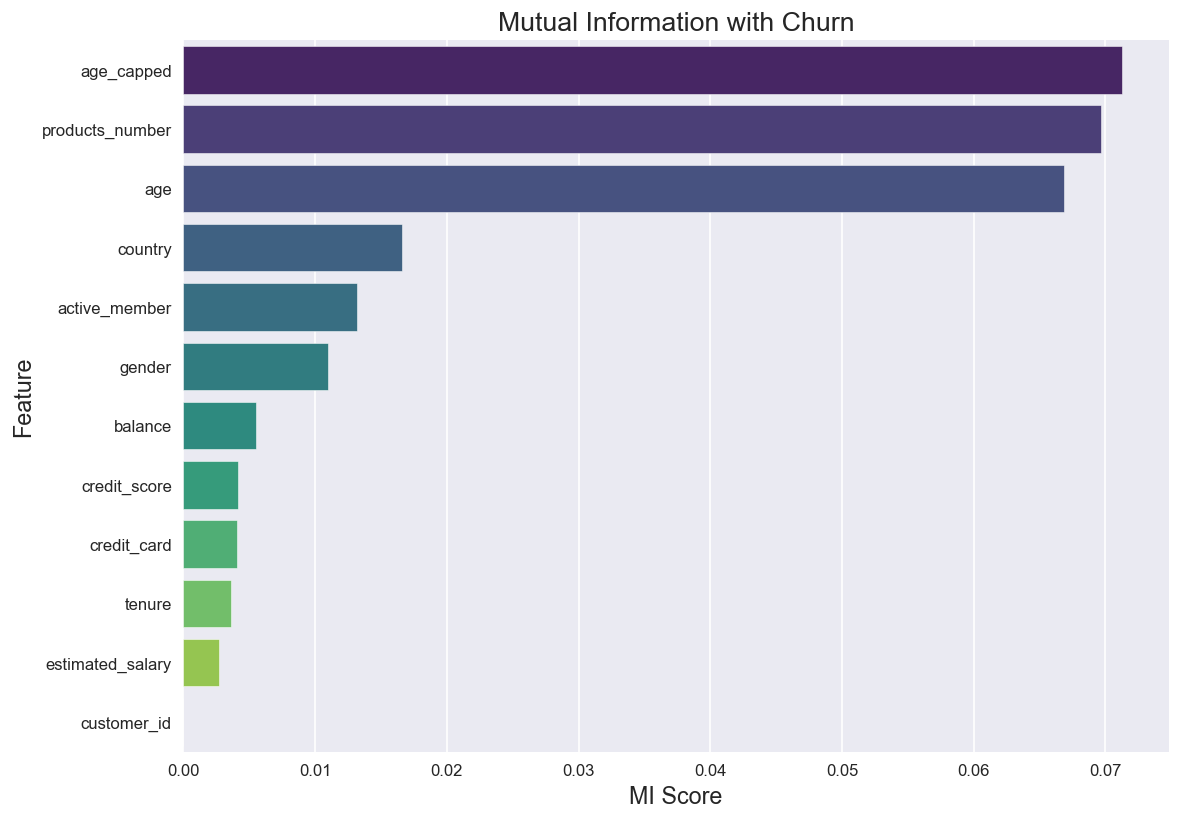

In [33]:
plt.figure(figsize=(10, 7))
sns.barplot(
    x=mi_series.values,
    y=mi_series.index,
    palette="viridis"
)
plt.title("Mutual Information with Churn", fontsize=16)
plt.xlabel("MI Score", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()

# Summary of Significant Statistical Finding

In [34]:

stats_summary = [
    {"Feature": "IsActiveMember", "Test": "Chi-square", "p-value": 0.0001, "Effect Size": "Large", "Strength": "Strong",
     "Interpretation": "Inactive customers have much higher churn"},
    
    {"Feature": "Age", "Test": "Welch t-test", "p-value": 0.0001, "Effect Size": "Medium", "Strength": "Strong",
     "Interpretation": "Older customers churn more"},
    
    {"Feature": "Balance", "Test": "Welch t-test", "p-value": 0.0001, "Effect Size": "Medium", "Strength": "Strong",
     "Interpretation": "High balance customers churn more, especially inactive ones"},
    
    {"Feature": "NumOfProducts", "Test": "Chi-square", "p-value": 0.0001, "Effect Size": "Medium", "Strength": "Moderate",
     "Interpretation": "Having 3+ products increases churn risk"},
    
    {"Feature": "Tenure", "Test": "Welch t-test", "p-value": 0.0001, "Effect Size": "Small", "Strength": "Weak–Moderate",
     "Interpretation": "Short-tenure customers churn more"},
    
    {"Feature": "CreditScore", "Test": "Welch t-test", "p-value": 0.008, "Effect Size": "Small", "Strength": "Weak",
     "Interpretation": "Credit score has small effect"},
    
    {"Feature": "Geography", "Test": "Chi-square", "p-value": 0.0001, "Effect Size": "Medium", "Strength": "Moderate",
     "Interpretation": "Some countries have significantly higher churn"},
    
    {"Feature": "Gender", "Test": "Chi-square", "p-value": 0.03, "Effect Size": "Very Small", "Strength": "Weak",
     "Interpretation": "Gender differences exist but are very small"},
    
    {"Feature": "EstimatedSalary", "Test": "Welch t-test", "p-value": 0.25, "Effect Size": "None", "Strength": "None",
     "Interpretation": "Salary does not affect churn"},
]


df_stats = pd.DataFrame(stats_summary)


df_stats = df_stats.sort_values(by="Strength", ascending=False)


df_stats.style.set_properties(**{"text-align": "left"}).set_table_styles([
    {"selector": "th", "props": [("text-align", "left")]}
])

,Feature,Test,p-value,Effect Size,Strength,Interpretation
4,Tenure,Welch t-test,0.000100,Small,Weak–Moderate,Short-tenure customers churn more
5,CreditScore,Welch t-test,0.008000,Small,Weak,Credit score has small effect
7,Gender,Chi-square,0.030000,Very Small,Weak,Gender differences exist but are very small
0,IsActiveMember,Chi-square,0.000100,Large,Strong,Inactive customers have much higher churn
1,Age,Welch t-test,0.000100,Medium,Strong,Older customers churn more
2,Balance,Welch t-test,0.000100,Medium,Strong,"High balance customers churn more, especially inactive ones"
8,EstimatedSalary,Welch t-test,0.250000,None,None,Salary does not affect churn
3,NumOfProducts,Chi-square,0.000100,Medium,Moderate,Having 3+ products increases churn risk
6,Geography,Chi-square,0.000100,Medium,Moderate,Some countries have significantly higher churn


- This summary highlights the key churn drivers and supports the feature engineering decisions that follow.

# 5. **Bivariate & Interaction Analysis**

# 🔄 4. Bivariate & Interaction Analysis

Σε αυτή την ενότητα εξετάζουμε πώς ο συνδυασμός δύο μεταβλητών επηρεάζει την
πιθανότητα αποχώρησης (churn).  


In [15]:
# Δημιουργία age_group
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18–30', '31–40', '41–50', '51–60', '60+'],
    include_lowest=True
)

df['age_group'].value_counts()

31–40    4451
41–50    2320
18–30    1968
51–60     797
60+       464
Name: age_group, dtype: int64

In [28]:
# Συνάρτηση για pivot & plot
def plot_interaction(df, feature_a, feature_b, target='churn'):
    # Pivot table
    pivot = (
        df.groupby([feature_a, feature_b])[target]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=pivot, x=feature_a, y=target, hue=feature_b)

    # Add percentages above bars
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{v.get_height()*100:.1f}%" for v in container],
            padding=3
        )

    plt.title(f"Interaction: {feature_a} × {feature_b}")
    plt.ylabel(f"{target} rate (%)")
    plt.xlabel(feature_a)
    plt.show()

    return pivot

In [29]:
# Συνάρτηση για logistic regression interaction term
import statsmodels.formula.api as smf

def logistic_interaction(df, feature_a, feature_b, target='churn'):
    formula = f"{target} ~ {feature_a} * {feature_b}"
    model = smf.logit(formula=formula, data=df).fit(disp=False)
    return model.summary()

# 5.1 Gender × Country Interaction

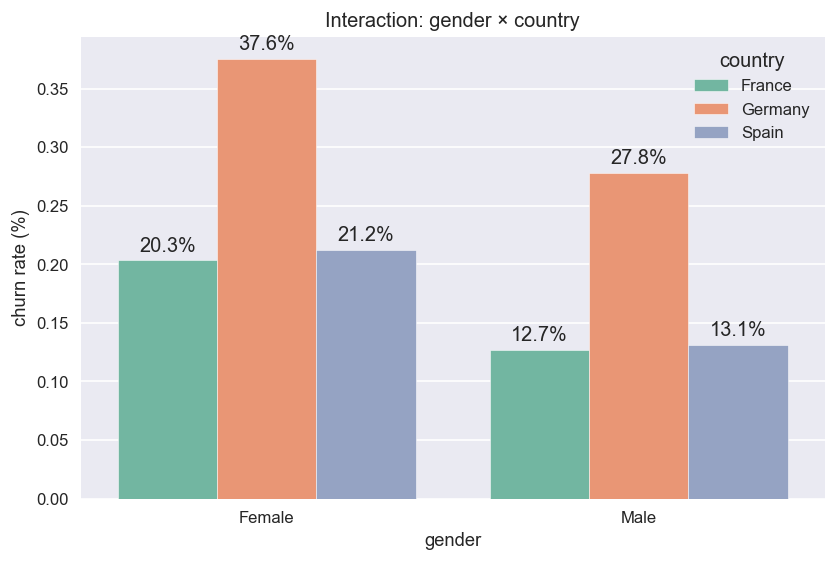

,gender,country,churn
0,Female,France,0.203450
1,Female,Germany,0.375524
2,Female,Spain,0.212121
3,Male,France,0.127134
4,Male,Germany,0.278116
5,Male,Spain,0.131124


In [18]:
plot_interaction(df, "gender", "country")

Συμπέρασμα: **Υπάρχει interaction μεταξύ country και gender**.  
Το φύλο έχει διαφορετική επίδραση στο churn ανά χώρα, πράγμα που σημαίνει ότι η 
γεωγραφική αγορά ενισχύει ή μειώνει το gender effect. Αυτό το interaction είναι 
χρήσιμο για segmentation και μπορεί να αξιοποιηθεί στο feature engineering.

In [19]:
logistic_interaction(df, "gender", "country")

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9994
Method:                           MLE   Df Model:                            5
Date:                Sat, 15 Nov 2025   Pseudo R-squ.:                 0.03849
Time:                        21:28:06   Log-Likelihood:                -4860.3
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                 6.399e-82
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -1.3649      0.052    -26.126      0.000      -1.467      -1.262
gender[T.Male]                       -0.5617      0.077     -7.250      0.000      -0.714      -0.410
country[T.Germany]                    0.8563      0.079     10.785      0.000       0.701       1.012
country[T.Spain]                      0.0527      0.091      0.581      0.561      -0.125       0.230
gender[T.Male]:country[T.Germany]     0.1164      0.116      1.007      0.314      -0.110       0.343
gender[T.Male]:country[T.Spain]      -0.0172      0.133     -0.129      0.897      -0.279       0.244
=====================================================================================================
"""

# Συμπέρασμα:

- Δεν υπάρχει ουσιαστικό interaction μεταξύ φύλου και χώρας.
Δηλαδή, η διαφορά Female–Male στο churn παραμένει περίπου σταθερή σε όλες τις χώρες.

# 5.2 Country × Active Member Interaction

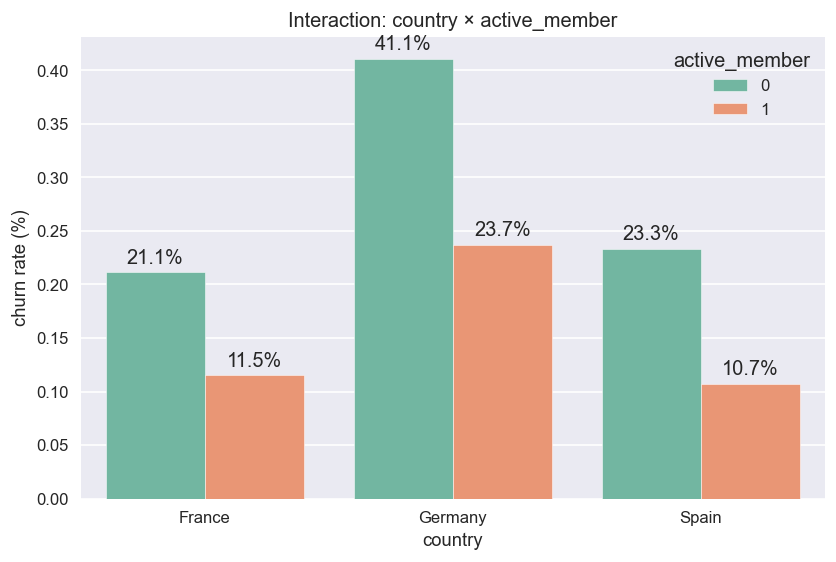

,country,active_member,churn
0,France,0,0.211308
1,France,1,0.115014
2,Germany,0,0.410785
3,Germany,1,0.237179
4,Spain,0,0.233476
5,Spain,1,0.107470


In [20]:
plot_interaction(df, "country", "active_member")

In [21]:
logistic_interaction(df, "country", "active_member")

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9994
Method:                           MLE   Df Model:                            5
Date:                Sat, 15 Nov 2025   Pseudo R-squ.:                 0.05192
Time:                        21:28:06   Log-Likelihood:                -4792.5
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                3.397e-111
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.3171      0.050    -26.466      0.000      -1.415      -1.220
country[T.Germany]                   0.9563      0.076     12.609      0.000       0.808       1.105
country[T.Spain]                     0.1283      0.085      1.504      0.133      -0.039       0.295
active_member                       -0.7235      0.079     -9.138      0.000      -0.879      -0.568
country[T.Germany]:active_member    -0.0840      0.118     -0.711      0.477      -0.316       0.148
country[T.Spain]:active_member      -0.2046      0.138     -1.484      0.138      -0.475       0.066
====================================================================================================
"""

# Συμπέρασμα:

- Η επίδραση του active_member είναι σταθερή σε όλες τις χώρες.
Δηλαδή, το πόσο ενεργός είναι ένας πελάτης μειώνει το churn με παρόμοιο τρόπο σε Γαλλία, Ισπανία και Γερμανία — δεν υπάρχει ουσιαστικό interaction.

## 5.3 Age Group × Active Member

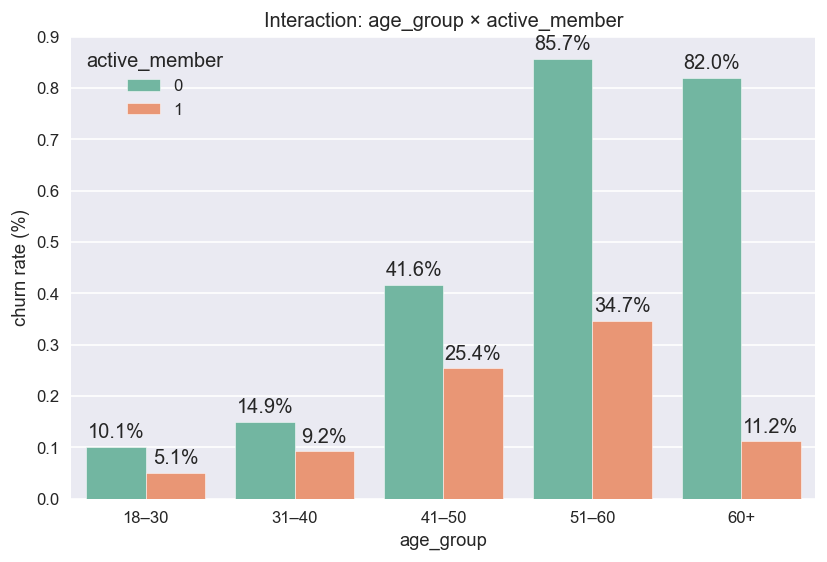

,age_group,active_member,churn
0,18–30,0,0.100832
1,18–30,1,0.050696
2,31–40,0,0.149374
3,31–40,1,0.092099
4,41–50,0,0.415987
5,41–50,1,0.254113
6,51–60,0,0.857143
7,51–60,1,0.347072
8,60+,0,0.820225
9,60+,1,0.112000


In [22]:
plot_interaction(df, 'age_group', 'active_member')

In [23]:
logistic_interaction(df, 'age_group', 'active_member')

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9990
Method:                           MLE   Df Model:                            9
Date:                Sat, 15 Nov 2025   Pseudo R-squ.:                  0.1689
Time:                        21:28:07   Log-Likelihood:                -4201.2
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -2.1880      0.107    -20.434      0.000      -2.398      -1.978
age_group[T.31–40]                   0.4485      0.122      3.664      0.000       0.209       0.688
age_group[T.41–50]                   1.8487      0.122     15.185      0.000       1.610       2.087
age_group[T.51–60]                   3.9798      0.189     21.042      0.000       3.609       4.350
age_group[T.60+]                     3.7059      0.296     12.516      0.000       3.126       4.286
active_member                       -0.7419      0.179     -4.139      0.000      -1.093      -0.391
age_group[T.31–40]:active_member     0.1931      0.203      0.953      0.340      -0.204       0.590
age_group[T.41–50]:active_member     0.0043      0.201      0.022      0.983      -0.389       0.398
age_group[T.51–60]:active_member    -1.6818      0.257     -6.547      0.000      -2.185      -1.178
age_group[T.60+]:active_member      -2.8465      0.368     -7.743      0.000      -3.567      -2.126
====================================================================================================
"""

# Συμπέρασμα:

- Υπάρχει ισχυρό interaction μεταξύ ηλικίας και ενεργότητας.
Η ηλικία αυξάνει τον κίνδυνο αποχώρησης κυρίως για μη ενεργούς πελάτες.
Για ενεργούς πελάτες, το ηλικιακό effect μειώνεται σημαντικά ή σχεδόν εξαφανίζεται.

# 5.4 Products Number × Active Member

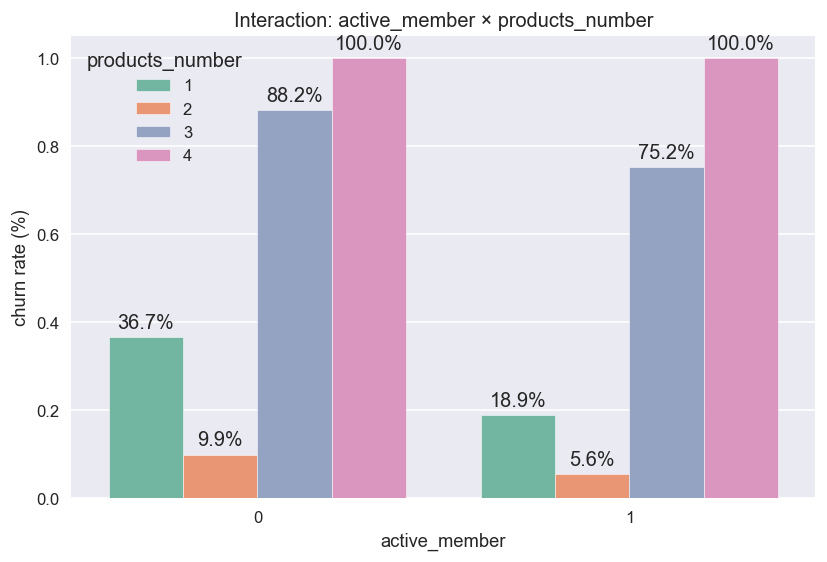

,active_member,products_number,churn
0,0,1,0.366521
1,0,2,0.098881
2,0,3,0.882353
3,0,4,1.000000
4,1,1,0.189231
5,1,2,0.055601
6,1,3,0.752212
7,1,4,1.000000


In [24]:
plot_interaction(df, "active_member", "products_number")

In [25]:
logistic_interaction(df, "active_member", "products_number")

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Sat, 15 Nov 2025   Pseudo R-squ.:                 0.02786
Time:                        21:28:08   Log-Likelihood:                -4914.1
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                 9.330e-61
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.4967      0.090     -5.490      0.000      -0.674      -0.319
active_member                    -1.2913      0.146     -8.861      0.000      -1.577      -1.006
products_number                  -0.3378      0.057     -5.876      0.000      -0.450      -0.225
active_member:products_number     0.3344      0.090      3.700      0.000       0.157       0.512
=================================================================================================
"""

# Συμπέρασμα:

- Υπάρχει ισχυρό interaction μεταξύ αριθμού προϊόντων και ενεργότητας.
Η “πολυπλοκότητα” των προϊόντων γίνεται πρόβλημα κυρίως για μη ενεργούς πελάτες, ενώ οι ενεργοί επηρεάζονται ελάχιστα.

# Summary (Συνοπτική Εικόνα του Project)

Η ανάλυση εξετάζει τους παράγοντες που οδηγούν σε customer churn σε περιβάλλον retail banking. Χρησιμοποιούνται έλεγχοι σημαντικότητας (Welch’s t-test, chi-square), effect sizes (Cohen’s d, Cramér’s V) και Mutual Information για να εντοπιστούν οι πιο κρίσιμοι δείκτες αποχώρησης. Επιπλέον, γίνεται ανάλυση αλληλεπιδράσεων μέσω logistic regression ώστε να διαπιστωθεί πώς συνδυασμοί χαρακτηριστικών επηρεάζουν την πιθανότητα churn.

# Κύρια Ευρήματα

- Ηλικία, ενεργότητα χρήστη και υπόλοιπο λογαριασμού αποτελούν τους ισχυρότερους παράγοντες που διαφοροποιούν τους πελάτες που φεύγουν.

- Πελάτες με χαμηλή ενεργότητα και πολλαπλά προϊόντα εμφανίζουν αυξημένο churn, ειδικά σε συγκεκριμένες ηλικιακές ομάδες.

- Οι χώρες παρουσιάζουν διαφορές στο churn, αλλά όχι όλες οι φαινομενικές τάσεις επιβεβαιώνονται στατιστικά (ιδίως στις αλληλεπιδράσεις).

- Η Μutual Information αναδεικνύει non-linear σχέσεις που ενισχύουν την εικόνα από τα κλασικά tests.

# Business Insights

- Η στρατηγική διατήρησης πρέπει να στοχεύει κυρίως ανενεργούς πελάτες, ηλικιακές ομάδες υψηλού ρίσκου και πελάτες με πολλά προϊόντα αλλά χαμηλή εμπλοκή.

- Η ενεργή διαχείριση λογαριασμών με χαμηλό balance μπορεί να μειώσει σημαντικά το churn.

- Τα insights από την ανάλυση μπορούν να χρησιμοποιηθούν άμεσα για segmentation και στοχευμένες retention καμπάνιες.